In [11]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Period & Domain

In [12]:
iyear=1960
fyear=2024
nx=10;ny=10
dom='GRp'
dom_NST = 'GRi'
year_NST = '2014'

# SF & RF & TF Data

In [13]:
RF = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/RF_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['RF']
RF = RF.rename({'TIME': 'time'})
RF = RF[:,ny:-ny,nx:-nx].sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))

SF = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/SF_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['SF']
SF = SF.rename({'TIME': 'time'})
SF = SF[:,ny:-ny,nx:-nx].sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))


#Compute Total Rainfall
TF = RF + SF

# Annual Mean

In [14]:
TF_mean = TF.groupby('time.year').mean('time', skipna=True)
TF_mean = TF_mean.mean(dim=['Y','X'], skipna=True)

SF_mean = SF.groupby('time.year').mean('time', skipna=True)
SF_mean = SF_mean.mean(dim=['Y','X'], skipna=True)

RF_mean = RF.groupby('time.year').mean('time', skipna=True)
RF_mean = RF_mean.mean(dim=['Y','X'], skipna=True)

R_mean = RF_mean / SF_mean * 100

# Trends

In [16]:
slope_RF, intercept_RF, r_value_RF, p_value_RF, std_err_RF = stats.linregress(RF_mean['year'].values, RF_mean.values)
trend_RF = intercept_RF + slope_RF * RF_mean['year'].values

slope_SF, intercept_SF, r_value_SF, p_value_SF, std_err_SF = stats.linregress(SF_mean['year'].values, SF_mean.values)
trend_SF = intercept_SF + slope_SF * SF_mean['year'].values

slope_TF, intercept_TF, r_value_TF, p_value_TF, std_err_TF = stats.linregress(TF_mean['year'].values, TF_mean.values)
trend_TF = intercept_TF + slope_TF * TF_mean['year'].values

slope_R, intercept_R, r_value_R, p_value_R, std_err_R = stats.linregress(R_mean['year'].values, R_mean.values)
trend_R = intercept_R + slope_R * R_mean['year'].values

# Statistics

In [17]:
mean_RF = np.mean(RF_mean.values)
std_RF = np.std(RF_mean.values)
min_RF = np.min(RF_mean.values)
max_RF = np.max(RF_mean.values)

mean_SF = np.mean(SF_mean.values)
std_SF = np.std(SF_mean.values)
min_SF = np.min(SF_mean.values)
max_SF = np.max(SF_mean.values)

mean_TF = np.mean(TF_mean.values)
std_TF = np.std(TF_mean.values)
min_TF = np.min(TF_mean.values)
max_TF = np.max(TF_mean.values)

mean_R = np.mean(R_mean.values)
std_R = np.std(R_mean.values)
min_R = np.min(R_mean.values)
max_R = np.max(R_mean.values)

RF : 0.09 mm / year / decade (p=0.046) (4.2 %/decade) (std=31.8 %)

SF : -0.12 mm / year / decade (p=0.446) (-0.7 %/decade) (std=13.9 %)

TF : -0.03 mm / year / decade (p=0.869) (-0.2 %/decade) (std=14.6 %)

R : 0.63 % / decade (p=0.004) (std=3.3 %)



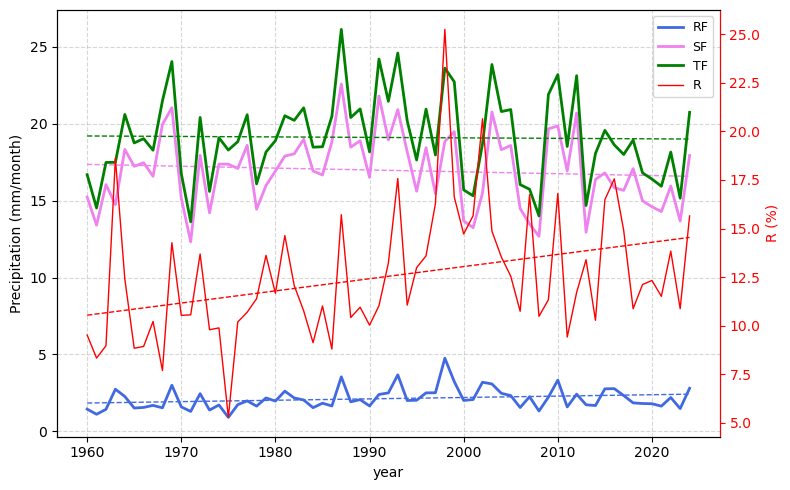

In [37]:
print(f'RF : {slope_RF * 10:.2f} mm / year / decade (p={p_value_RF:.3f}) ({(slope_RF*10)/mean_RF*100:.1f} %/decade) (std={std_RF/mean_RF*100:.1f} %)\n')
print(f'SF : {slope_SF * 10:.2f} mm / year / decade (p={p_value_SF:.3f}) ({(slope_SF*10)/mean_SF*100:.1f} %/decade) (std={std_SF/mean_SF*100:.1f} %)\n')
print(f'TF : {slope_TF * 10:.2f} mm / year / decade (p={p_value_TF:.3f}) ({(slope_TF*10)/mean_TF*100:.1f} %/decade) (std={std_TF/mean_TF*100:.1f} %)\n')
print(f'R : {slope_R * 10:.2f} % / decade (p={p_value_R:.3f}) (std={std_R:.1f} %)\n')

fig, ax = plt.subplots(figsize=(8,5))

ax2 = ax.twinx()  # axe droit
# mettre l'axe droit en red
ax2.tick_params(axis='y', colors='red')
ax2.yaxis.label.set_color('red')
ax2.spines['right'].set_color('red')

ax.plot(RF_mean['year'].values, RF_mean.values, color='royalblue', label='RF', linewidth=2)
ax.plot(RF_mean['year'].values, trend_RF, color='royalblue', linewidth=1, linestyle='--')

ax.plot(SF_mean['year'].values, SF_mean.values, color='violet', label='SF', linewidth=2)
ax.plot(SF_mean['year'].values, trend_SF, color='violet', linewidth=1, linestyle='--')

ax.plot(TF_mean['year'].values, TF_mean.values, color='green', label='TF', linewidth=2)
ax.plot(TF_mean['year'].values, trend_TF, color='green', linewidth=1, linestyle='--')

ax2.plot(R_mean['year'].values, R_mean.values, color='red', label='R', linewidth=1)
ax2.plot(R_mean['year'].values, trend_R, color='red', linewidth=1, linestyle='--')

ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_xlabel('year')
ax.set_ylabel('Precipitation (mm/month)')
ax2.set_ylabel('R (%)')

# --- legend
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.show()

# Evolution of freezing level height (FLH)

In [40]:
FLH = pd.read_csv(f'/bettik/PROJECTS/pr-regional-climate/bricej/MAR/FLH_monthly_timeseries_MAR_1960-2024_GRp.csv', parse_dates=["time"])
FLH = FLH.set_index('time')

In [41]:
# Annual mean over study period for FLH computed by MAR 
FLH_mean = FLH.groupby(FLH.index.year)['FLH'].mean().reset_index()
FLH_mean.columns = ['year', 'FLH']

#trend
slope_FLH, intercept_FLH, r_value_FLH, p_value_FLH, std_err_FLH = stats.linregress(FLH_mean['year'].values, FLH_mean['FLH'].values)
trend_FLH = intercept_FLH + slope_FLH * FLH_mean['year'].values

#statistics
mean_FLH = np.mean(FLH_mean['FLH'].values)
std_FLH = np.std(FLH_mean['FLH'].values)
min_FLH = np.min(FLH_mean['FLH'].values)
max_FLH = np.max(FLH_mean['FLH'].values)

RF : 10.62 m / decade (p=0.364) (0.3 %/decade) (std=5.2 %)



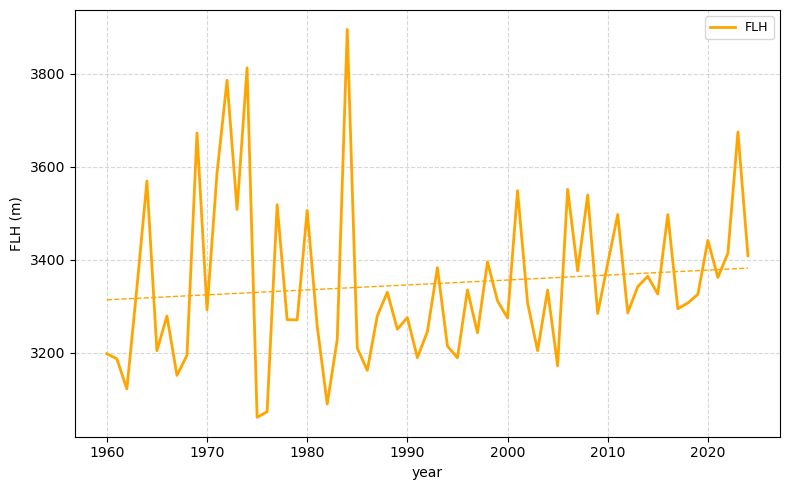

In [42]:
print(f'RF : {slope_FLH * 10:.2f} m / decade (p={p_value_FLH:.3f}) ({(slope_FLH*10)/mean_FLH*100:.1f} %/decade) (std={std_FLH/mean_FLH*100:.1f} %)\n')

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(FLH_mean['year'].values, FLH_mean['FLH'].values, color='orange', label='FLH', linewidth=2)
ax.plot(FLH_mean['year'].values, trend_FLH, color='orange', linewidth=1, linestyle='--')

ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_xlabel('year')
ax.set_ylabel('FLH (m)')

# --- legend
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Monthly timeseries

In [57]:
RF_monthly_timeseries = {}
SF_monthly_timeseries = {}
TF_monthly_timeseries = {}
R_monthly_timeseries = {}

for i in np.arange(1,13):
    
    # Selection of a single month through the all period
    RF_month = RF.sel(time=RF.time.dt.month == i)
    SF_month = SF.sel(time=SF.time.dt.month == i)
    TF_month = TF.sel(time=RF.time.dt.month == i)
    
    # Monthly mean for month i
    RF_monthly = RF_month.groupby('time.year').mean('time', skipna=True)
    RF_monthly = RF_monthly.mean(dim=['Y','X'], skipna=True)
    
    SF_monthly = SF_month.groupby('time.year').mean('time', skipna=True)
    SF_monthly = SF_monthly.mean(dim=['Y','X'], skipna=True)
    
    TF_monthly = TF_month.groupby('time.year').mean('time', skipna=True)
    TF_monthly = TF_monthly.mean(dim=['Y','X'], skipna=True)
    
    R_monthly = RF_monthly / SF_monthly * 100

    RF_monthly_timeseries[i] = RF_monthly
    SF_monthly_timeseries[i] = SF_monthly
    TF_monthly_timeseries[i] = TF_monthly
    R_monthly_timeseries[i] = R_monthly

# Monthly trends

In [59]:
RF_monthly_trends = {}
SF_monthly_trends = {}
TF_monthly_trends = {}
R_monthly_trends = {}

RF_monthly_trends_stats = {}
SF_monthly_trends_stats = {}
TF_monthly_trends_stats = {}
R_monthly_trends_stats = {}

for i in np.arange(1,13):

    slope_month_RF, intercept_month_RF, r_value_month_RF, p_value_month_RF, std_err_month_RF = stats.linregress(RF_monthly_timeseries[i]['year'].values, RF_monthly_timeseries[i].values)
    trend_month_RF = intercept_month_RF + slope_month_RF * RF_monthly_timeseries[i]['year'].values
    
    slope_month_SF, intercept_month_SF, r_value_month_SF, p_value_month_SF, std_err_month_SF = stats.linregress(SF_monthly_timeseries[i]['year'].values, SF_monthly_timeseries[i].values)
    trend_month_SF = intercept_month_SF + slope_month_SF * SF_monthly_timeseries[i]['year'].values
    
    slope_month_TF, intercept_month_TF, r_value_month_TF, p_value_month_TF, std_err_month_TF = stats.linregress(TF_monthly_timeseries[i]['year'].values, TF_monthly_timeseries[i].values)
    trend_month_TF = intercept_month_TF + slope_month_TF * TF_monthly_timeseries[i]['year'].values
    
    slope_month_R, intercept_month_R, r_value_month_R, p_value_month_R, std_err_month_R = stats.linregress(R_monthly_timeseries[i]['year'].values, R_monthly_timeseries[i].values)
    trend_month_R = intercept_month_R + slope_month_R * R_monthly_timeseries[i]['year'].values

    RF_monthly_trends_stats[i] = [slope_month_RF, intercept_month_RF, r_value_month_RF, p_value_month_RF, std_err_month_RF]
    SF_monthly_trends_stats[i] = [slope_month_SF, intercept_month_SF, r_value_month_SF, p_value_month_SF, std_err_month_SF]
    TF_monthly_trends_stats[i] = [slope_month_TF, intercept_month_TF, r_value_month_TF, p_value_month_TF, std_err_month_TF]
    R_monthly_trends_stats[i] = [slope_month_R, intercept_month_R, r_value_month_R, p_value_month_R, std_err_month_R]

    RF_monthly_trends[i] = trend_month_RF
    SF_monthly_trends[i] = trend_month_SF
    TF_monthly_trends[i] = trend_month_TF
    R_monthly_trends[i] = trend_month_R

# Monthly statistics

In [61]:
RF_monthly_stats = {}
SF_monthly_stats = {}
TF_monthly_stats = {}
R_monthly_stats = {}

for i in np.arange(1,13):

    mean_month_RF = np.mean(RF_monthly_timeseries[i].values)
    std_month_RF = np.std(RF_monthly_timeseries[i].values)
    min_month_RF = np.min(RF_monthly_timeseries[i].values)
    max_month_RF = np.max(RF_monthly_timeseries[i].values)
    
    mean_month_SF = np.mean(SF_monthly_timeseries[i].values)
    std_month_SF = np.std(SF_monthly_timeseries[i].values)
    min_month_SF = np.min(SF_monthly_timeseries[i].values)
    max_month_SF = np.max(SF_monthly_timeseries[i].values)
    
    mean_month_TF = np.mean(TF_monthly_timeseries[i].values)
    std_month_TF = np.std(TF_monthly_timeseries[i].values)
    min_month_TF = np.min(TF_monthly_timeseries[i].values)
    max_month_TF = np.max(TF_monthly_timeseries[i].values)
    
    mean_month_R = np.mean(R_monthly_timeseries[i].values)
    std_month_R = np.std(R_monthly_timeseries[i].values)
    min_month_R = np.min(R_monthly_timeseries[i].values)
    max_month_R = np.max(R_monthly_timeseries[i].values)

    RF_monthly_stats[i] = [mean_month_RF, std_month_RF, min_month_RF, max_month_RF]
    SF_monthly_stats[i] = [mean_month_SF, std_month_SF, min_month_SF, max_month_SF]
    TF_monthly_stats[i] = [mean_month_TF, std_month_TF, min_month_TF, max_month_TF]
    R_monthly_stats[i] = [mean_month_R, std_month_R, min_month_R, max_month_R]

==================================================== RF =================================================


,slope (mm/month/decade),slope (%/decade),std (mm/month),std (%)
Jan,0.02,13.7,0.16,136.2
Feb,0.03,5.8,0.47,89.9
Mar,-0.02,-0.8,1.32,65.0
Apr,-0.22,-5.2,2.35,54.8
May,-0.00,-0.1,3.01,53.5
Jun,0.46,12.3,2.45,65.8
Jul,0.27,7.6,2.78,77.2
Aug,0.42,15.3,2.15,78.6
Sep,0.06,5.8,0.78,72.5
Oct,-0.01,-1.1,1.02,109.6


==================================================== SF =================================================


,slope (mm/month/decade),slope (%/decade),std (mm/month),std (%)
Jan,0.10,0.5,7.33,41.2
Feb,0.28,1.1,8.68,35.3
Mar,-1.31,-4.1,11.16,35.2
Apr,-0.67,-2.3,9.78,33.0
May,-0.94,-3.4,10.44,38.3
Jun,1.07,7.6,7.63,54.4
Jul,-0.21,-3.6,4.97,83.0
Aug,0.29,7.7,2.97,78.4
Sep,-0.03,-0.5,3.49,66.5
Oct,-0.14,-1.2,7.34,60.4


==================================================== TF =================================================


,slope (mm/month/decade),slope (%/decade),std (mm/month),std (%)
Jan,0.11,0.6,7.39,41.2
Feb,0.31,1.2,8.88,35.4
Mar,-1.32,-3.9,11.92,35.3
Apr,-0.90,-2.6,11.26,33.2
May,-0.94,-2.9,12.46,37.9
Jun,1.52,8.6,9.43,53.2
Jul,0.06,0.6,7.10,74.0
Aug,0.71,10.9,4.53,69.4
Sep,0.03,0.5,4.05,64.0
Oct,-0.15,-1.2,8.20,62.7


==================================================== R =================================================


,slope (%/decade),std (%)
Jan,0.06,0.89
Feb,0.04,2.00
Mar,0.25,3.28
Apr,-0.48,6.75
May,0.48,8.55
Jun,1.37,13.17
Jul,8.92,54.06
Aug,3.08,70.30
Sep,2.04,16.86
Oct,0.26,4.71


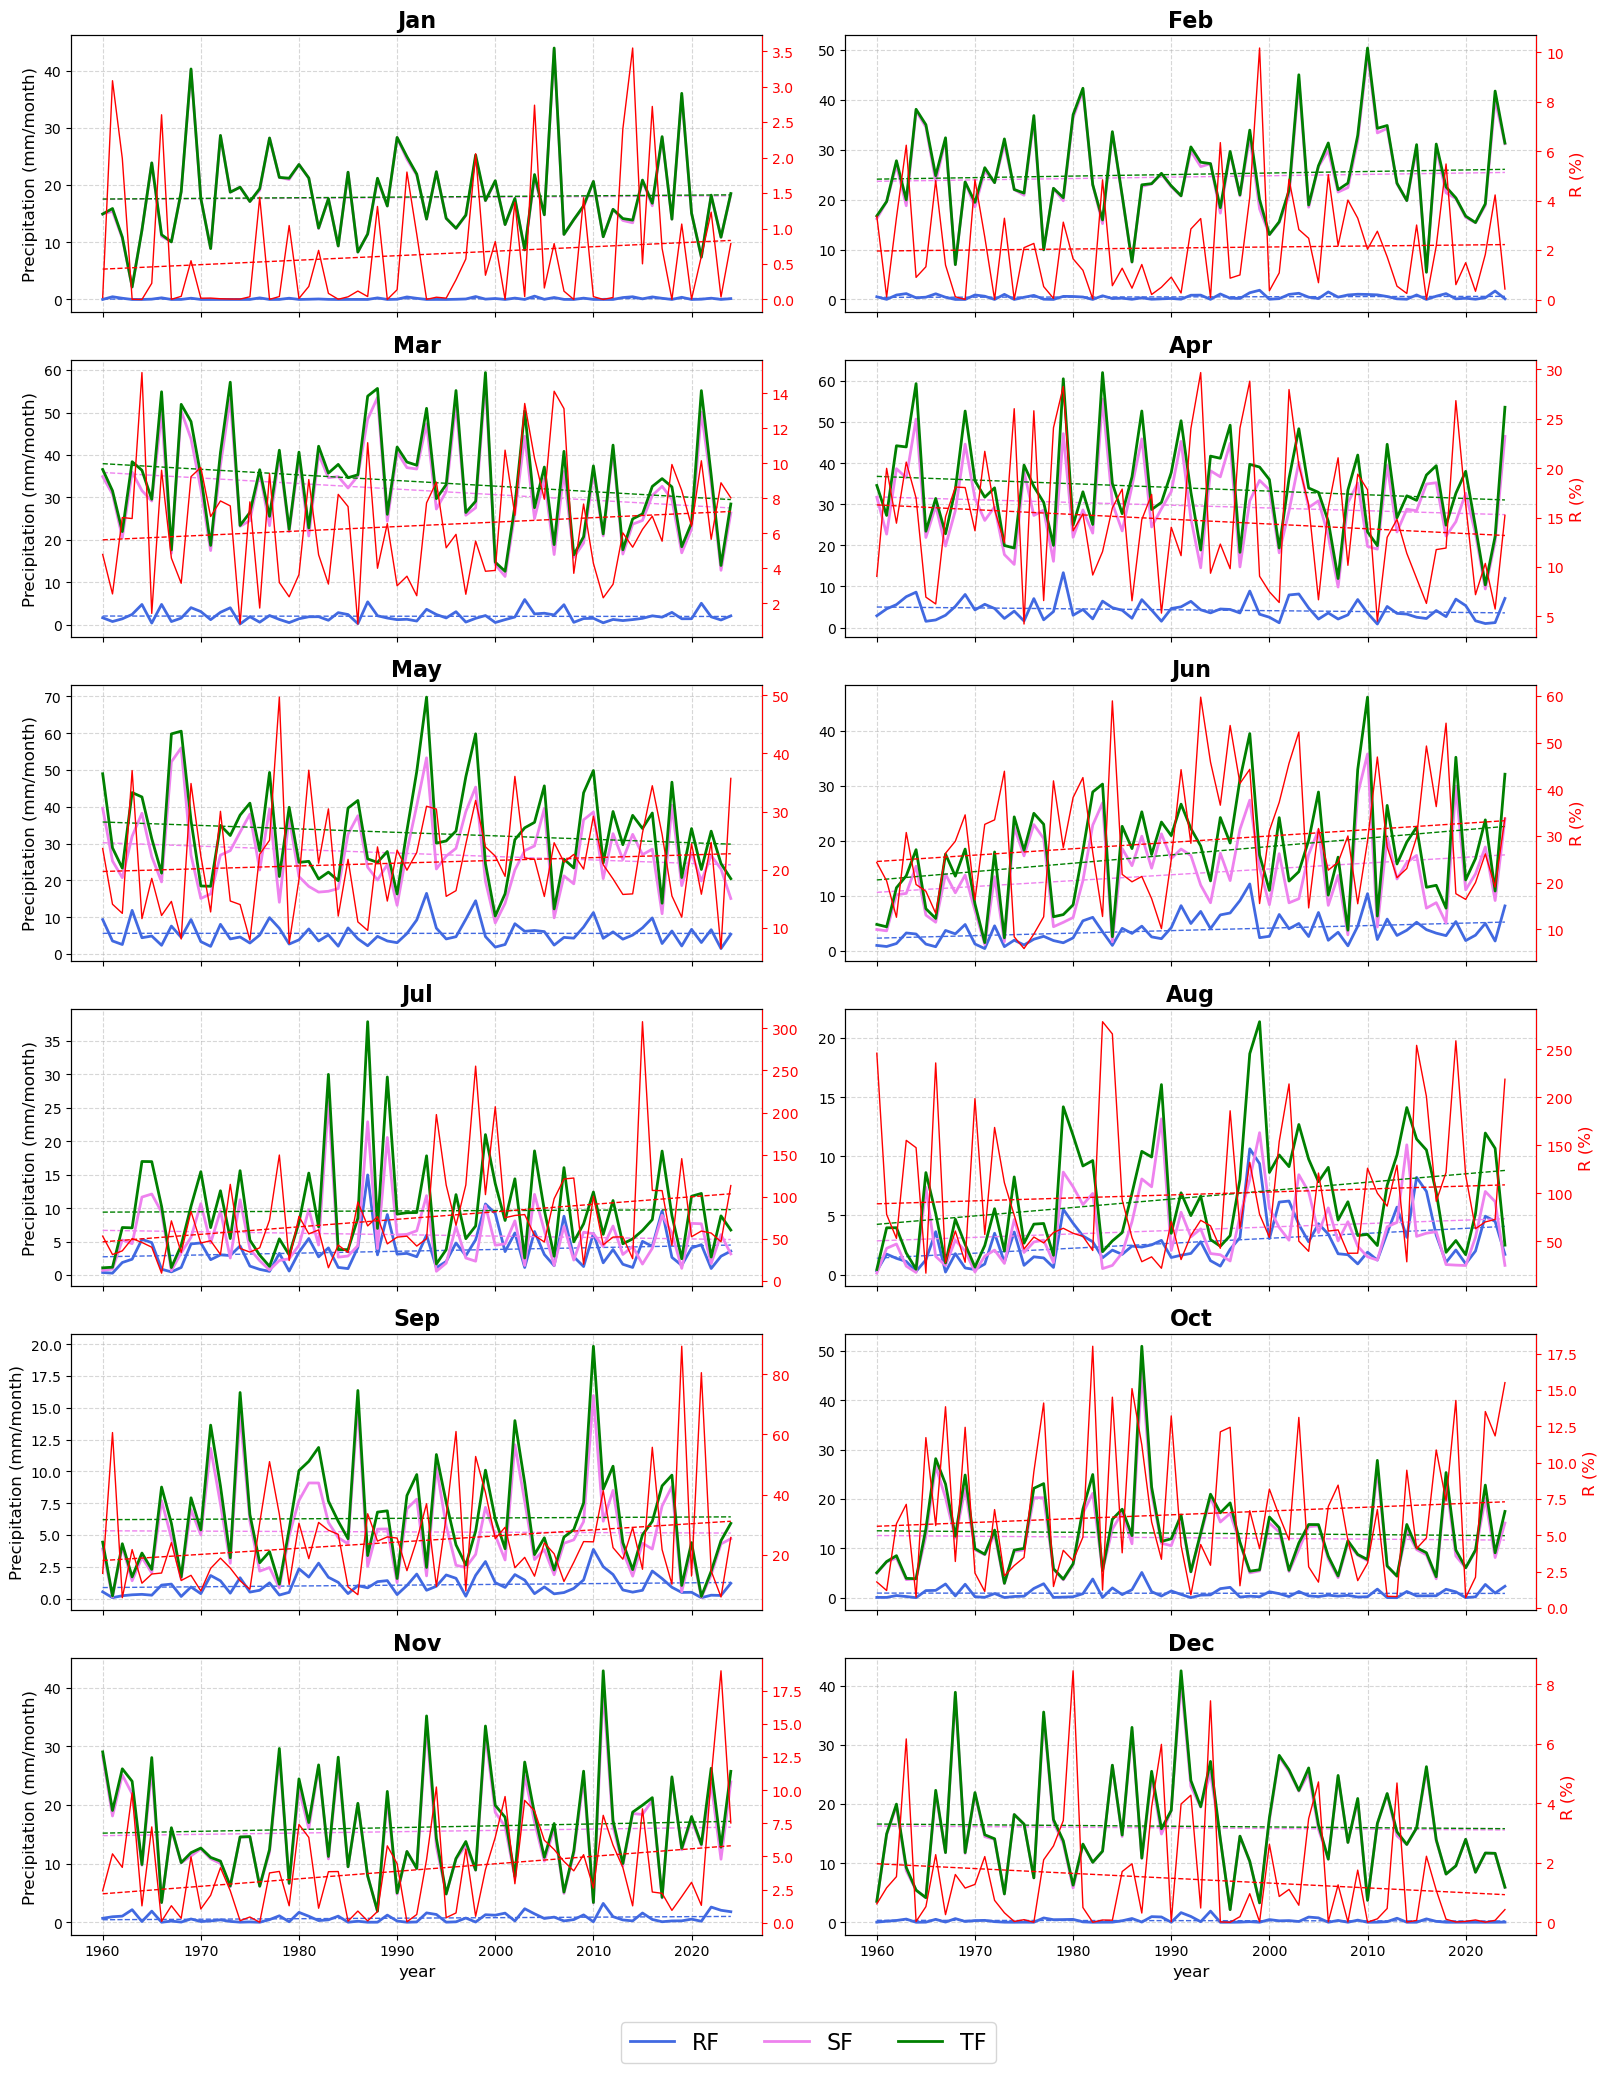

In [95]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

#====================== statistics tab ==============================================================================

def bold_sig(val, p):
    if p < 0.05:
        return 'font-weight: bold'
    return ''

#========= RF ================
print('==================================================== RF =================================================')

table = pd.DataFrame(index=months, columns=['slope (mm/month/decade)', 'slope (%/decade)', 'std (mm/month)', 'std (%)'])
pvals = pd.DataFrame(index=months, columns=['slope (mm/month/decade)', 'slope (%/decade)', 'std (mm/month)', 'std (%)'])

for i in np.arange(1,13):

    RF_slope = RF_monthly_trends_stats[i][0] * 10
    RF_pval  = RF_monthly_trends_stats[i][3]
    RF_slope_percentage = RF_slope /  RF_monthly_stats[i][0] * 100
    RF_std = RF_monthly_stats[i][1]
    RF_std_percentage = RF_std /  RF_monthly_stats[i][0] * 100

    table.loc[months[i-1], 'slope (mm/month/decade)'] = RF_slope
    table.loc[months[i-1], 'slope (%/decade)'] = RF_slope_percentage
    table.loc[months[i-1], 'std (mm/month)'] = RF_std
    table.loc[months[i-1], 'std (%)'] = RF_std_percentage

    
    pvals.loc[months[i-1], 'slope (mm/month/decade)'] = RF_pval
    pvals.loc[months[i-1], 'slope (%/decade)'] = RF_pval

formats = {
    'slope (mm/month/decade)': "{:.2f}",
    'slope (%/decade)': "{:.1f}",
    'std (mm/month)': "{:.2f}",      
    'std (%)': "{:.1f}"
}

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format(formats, na_rep='-')

display(styled_table)

#========= SF ================
print('==================================================== SF =================================================')

table = pd.DataFrame(index=months, columns=['slope (mm/month/decade)', 'slope (%/decade)', 'std (mm/month)', 'std (%)'])
pvals = pd.DataFrame(index=months, columns=['slope (mm/month/decade)', 'slope (%/decade)', 'std (mm/month)', 'std (%)'])

for i in np.arange(1,13):

    SF_slope = SF_monthly_trends_stats[i][0] * 10
    SF_pval  = SF_monthly_trends_stats[i][3]
    SF_slope_percentage = SF_slope /  SF_monthly_stats[i][0] * 100
    SF_std = SF_monthly_stats[i][1]
    SF_std_percentage = SF_std /  SF_monthly_stats[i][0] * 100

    table.loc[months[i-1], 'slope (mm/month/decade)'] = SF_slope
    table.loc[months[i-1], 'slope (%/decade)'] = SF_slope_percentage
    table.loc[months[i-1], 'std (mm/month)'] = SF_std
    table.loc[months[i-1], 'std (%)'] = SF_std_percentage

    
    pvals.loc[months[i-1], 'slope (mm/month/decade)'] = SF_pval
    pvals.loc[months[i-1], 'slope (%/decade)'] = SF_pval

formats = {
    'slope (mm/month/decade)': "{:.2f}",
    'slope (%/decade)': "{:.1f}",
    'std (mm/month)': "{:.2f}",      
    'std (%)': "{:.1f}"
}

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format(formats, na_rep='-')

display(styled_table)

#========= TF ================
print('==================================================== TF =================================================')

table = pd.DataFrame(index=months, columns=['slope (mm/month/decade)', 'slope (%/decade)', 'std (mm/month)', 'std (%)'])
pvals = pd.DataFrame(index=months, columns=['slope (mm/month/decade)', 'slope (%/decade)', 'std (mm/month)', 'std (%)'])

for i in np.arange(1,13):

    TF_slope = TF_monthly_trends_stats[i][0] * 10
    TF_pval  = TF_monthly_trends_stats[i][3]
    TF_slope_percentage = TF_slope /  TF_monthly_stats[i][0] * 100
    TF_std = TF_monthly_stats[i][1]
    TF_std_percentage = TF_std /  TF_monthly_stats[i][0] * 100

    table.loc[months[i-1], 'slope (mm/month/decade)'] = TF_slope
    table.loc[months[i-1], 'slope (%/decade)'] = TF_slope_percentage
    table.loc[months[i-1], 'std (mm/month)'] = TF_std
    table.loc[months[i-1], 'std (%)'] = TF_std_percentage

    
    pvals.loc[months[i-1], 'slope (mm/month/decade)'] = TF_pval
    pvals.loc[months[i-1], 'slope (%/decade)'] = TF_pval

formats = {
    'slope (mm/month/decade)': "{:.2f}",
    'slope (%/decade)': "{:.1f}",
    'std (mm/month)': "{:.2f}",      
    'std (%)': "{:.1f}"
}

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format(formats, na_rep='-')

display(styled_table)

#========= R ================
print('==================================================== R =================================================')

table = pd.DataFrame(index=months, columns=['slope (%/decade)', 'std (%)'])
pvals = pd.DataFrame(index=months, columns=['slope (%/decade)', 'std (%)'])

for i in np.arange(1,13):

    R_slope = R_monthly_trends_stats[i][0] * 10
    R_pval  = R_monthly_trends_stats[i][3]
    R_std = R_monthly_stats[i][1]

    table.loc[months[i-1], 'slope (%/decade)'] = R_slope
    table.loc[months[i-1], 'std (%)'] = R_std
    
    pvals.loc[months[i-1], 'slope (%/decade)'] = R_pval

formats = {
    'slope (%/decade)': "{:.2f}",
    'std (%)': "{:.2f}",      
}

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format(formats, na_rep='-')

display(styled_table)

#======================== plot ============================================================================================

fig, axes = plt.subplots(6, 2, figsize=(16,20))
axes = axes.flatten()

for i, ax in enumerate(axes):
    
    ax2 = ax.twinx()  # axe droit
    # mettre l'axe droit en red
    ax2.tick_params(axis='y', colors='red')
    ax2.yaxis.label.set_color('red')
    ax2.spines['right'].set_color('red')
    
    ax.plot(RF_monthly_timeseries[i+1]['year'].values, RF_monthly_timeseries[i+1].values, color='royalblue', label='RF', linewidth=2)
    ax.plot(RF_monthly_timeseries[i+1]['year'].values, RF_monthly_trends[i+1], color='royalblue', linewidth=1, linestyle='--')
    
    ax.plot(SF_monthly_timeseries[i+1]['year'].values, SF_monthly_timeseries[i+1].values, color='violet', label='SF', linewidth=2)
    ax.plot(SF_monthly_timeseries[i+1]['year'].values, SF_monthly_trends[i+1], color='violet', linewidth=1, linestyle='--')
    
    ax.plot(TF_monthly_timeseries[i+1]['year'].values, TF_monthly_timeseries[i+1].values, color='green', label='TF', linewidth=2)
    ax.plot(TF_monthly_timeseries[i+1]['year'].values, TF_monthly_trends[i+1], color='green', linewidth=1, linestyle='--')
    
    ax2.plot(R_monthly_timeseries[i+1]['year'].values, R_monthly_timeseries[i+1].values, color='red', label='R', linewidth=1)
    ax2.plot(R_monthly_timeseries[i+1]['year'].values, R_monthly_trends[i+1], color='red', linewidth=1, linestyle='--')

    ax.set_title(months[i], fontsize=16, weight="bold")
    
    if i in [0, 2, 4, 6, 8, 10]:  # colonne gauche
        ax.set_ylabel('Precipitation (mm/month)', fontsize=12)

    if i in [1, 3, 5, 7, 9, 11]:  # colonne droite
        ax2.set_ylabel('R (%)', fontsize=12)
        
    if i in [10, 11]:  # ligne du bas
        ax.set_xlabel('year', fontsize=12)
    else:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    
# --- legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
    
plt.tight_layout()
plt.show()

# Monthly evolution of freezing level height (FLH)

In [75]:
FLH_monthly_timeseries = {}

FLH_monthly_trends = {}
FLH_monthly_trends_stats = {}

FLH_monthly_stats = {}

for i in np.arange(1,13):

    # Selection du i-ème mois
    FLH_monthly = FLH[FLH.index.month == i] 
    FLH_monthly = FLH_monthly.groupby(FLH_monthly.index.year)['FLH'].mean().reset_index()
    FLH_monthly.columns = ['year', 'FLH']
    
    #trend
    FLH_monthly = FLH_monthly[['year', 'FLH']].dropna()
    slope_month_FLH, intercept_month_FLH, r_value_month_FLH, p_value_month_FLH, std_err_month_FLH = stats.linregress(FLH_monthly['year'].values, FLH_monthly['FLH'].values)
    trend_month_FLH = intercept_month_FLH + slope_month_FLH * FLH_monthly['year'].values
    
    #statistics
    mean_month_FLH = np.mean(FLH_monthly['FLH'].values)
    std_month_FLH = np.std(FLH_monthly['FLH'].values)
    min_month_FLH = np.min(FLH_monthly['FLH'].values)
    max_month_FLH = np.max(FLH_monthly['FLH'].values)

    FLH_monthly_timeseries[i] = FLH_monthly

    FLH_monthly_trends[i] = trend_month_FLH
    FLH_monthly_trends_stats[i] = [slope_month_FLH, intercept_month_FLH, r_value_month_FLH, p_value_month_FLH, std_err_month_FLH]
    
    FLH_monthly_stats[i] = [mean_month_FLH, std_month_FLH, min_month_FLH, max_month_FLH]
    

,slope (m/decade),slope (%/decade),std (m),std (%)
Jan,31,2.5,251,19.9
Feb,40,2.3,402,23.3
Mar,47,1.8,267,10.4
Apr,16,0.5,183,5.5
May,34,0.8,236,5.9
Jun,8,0.2,120,2.6
Jul,15,0.3,106,2.1
Aug,5,0.1,85,1.7
Sep,27,0.6,142,3.2
Oct,22,0.7,169,5.0


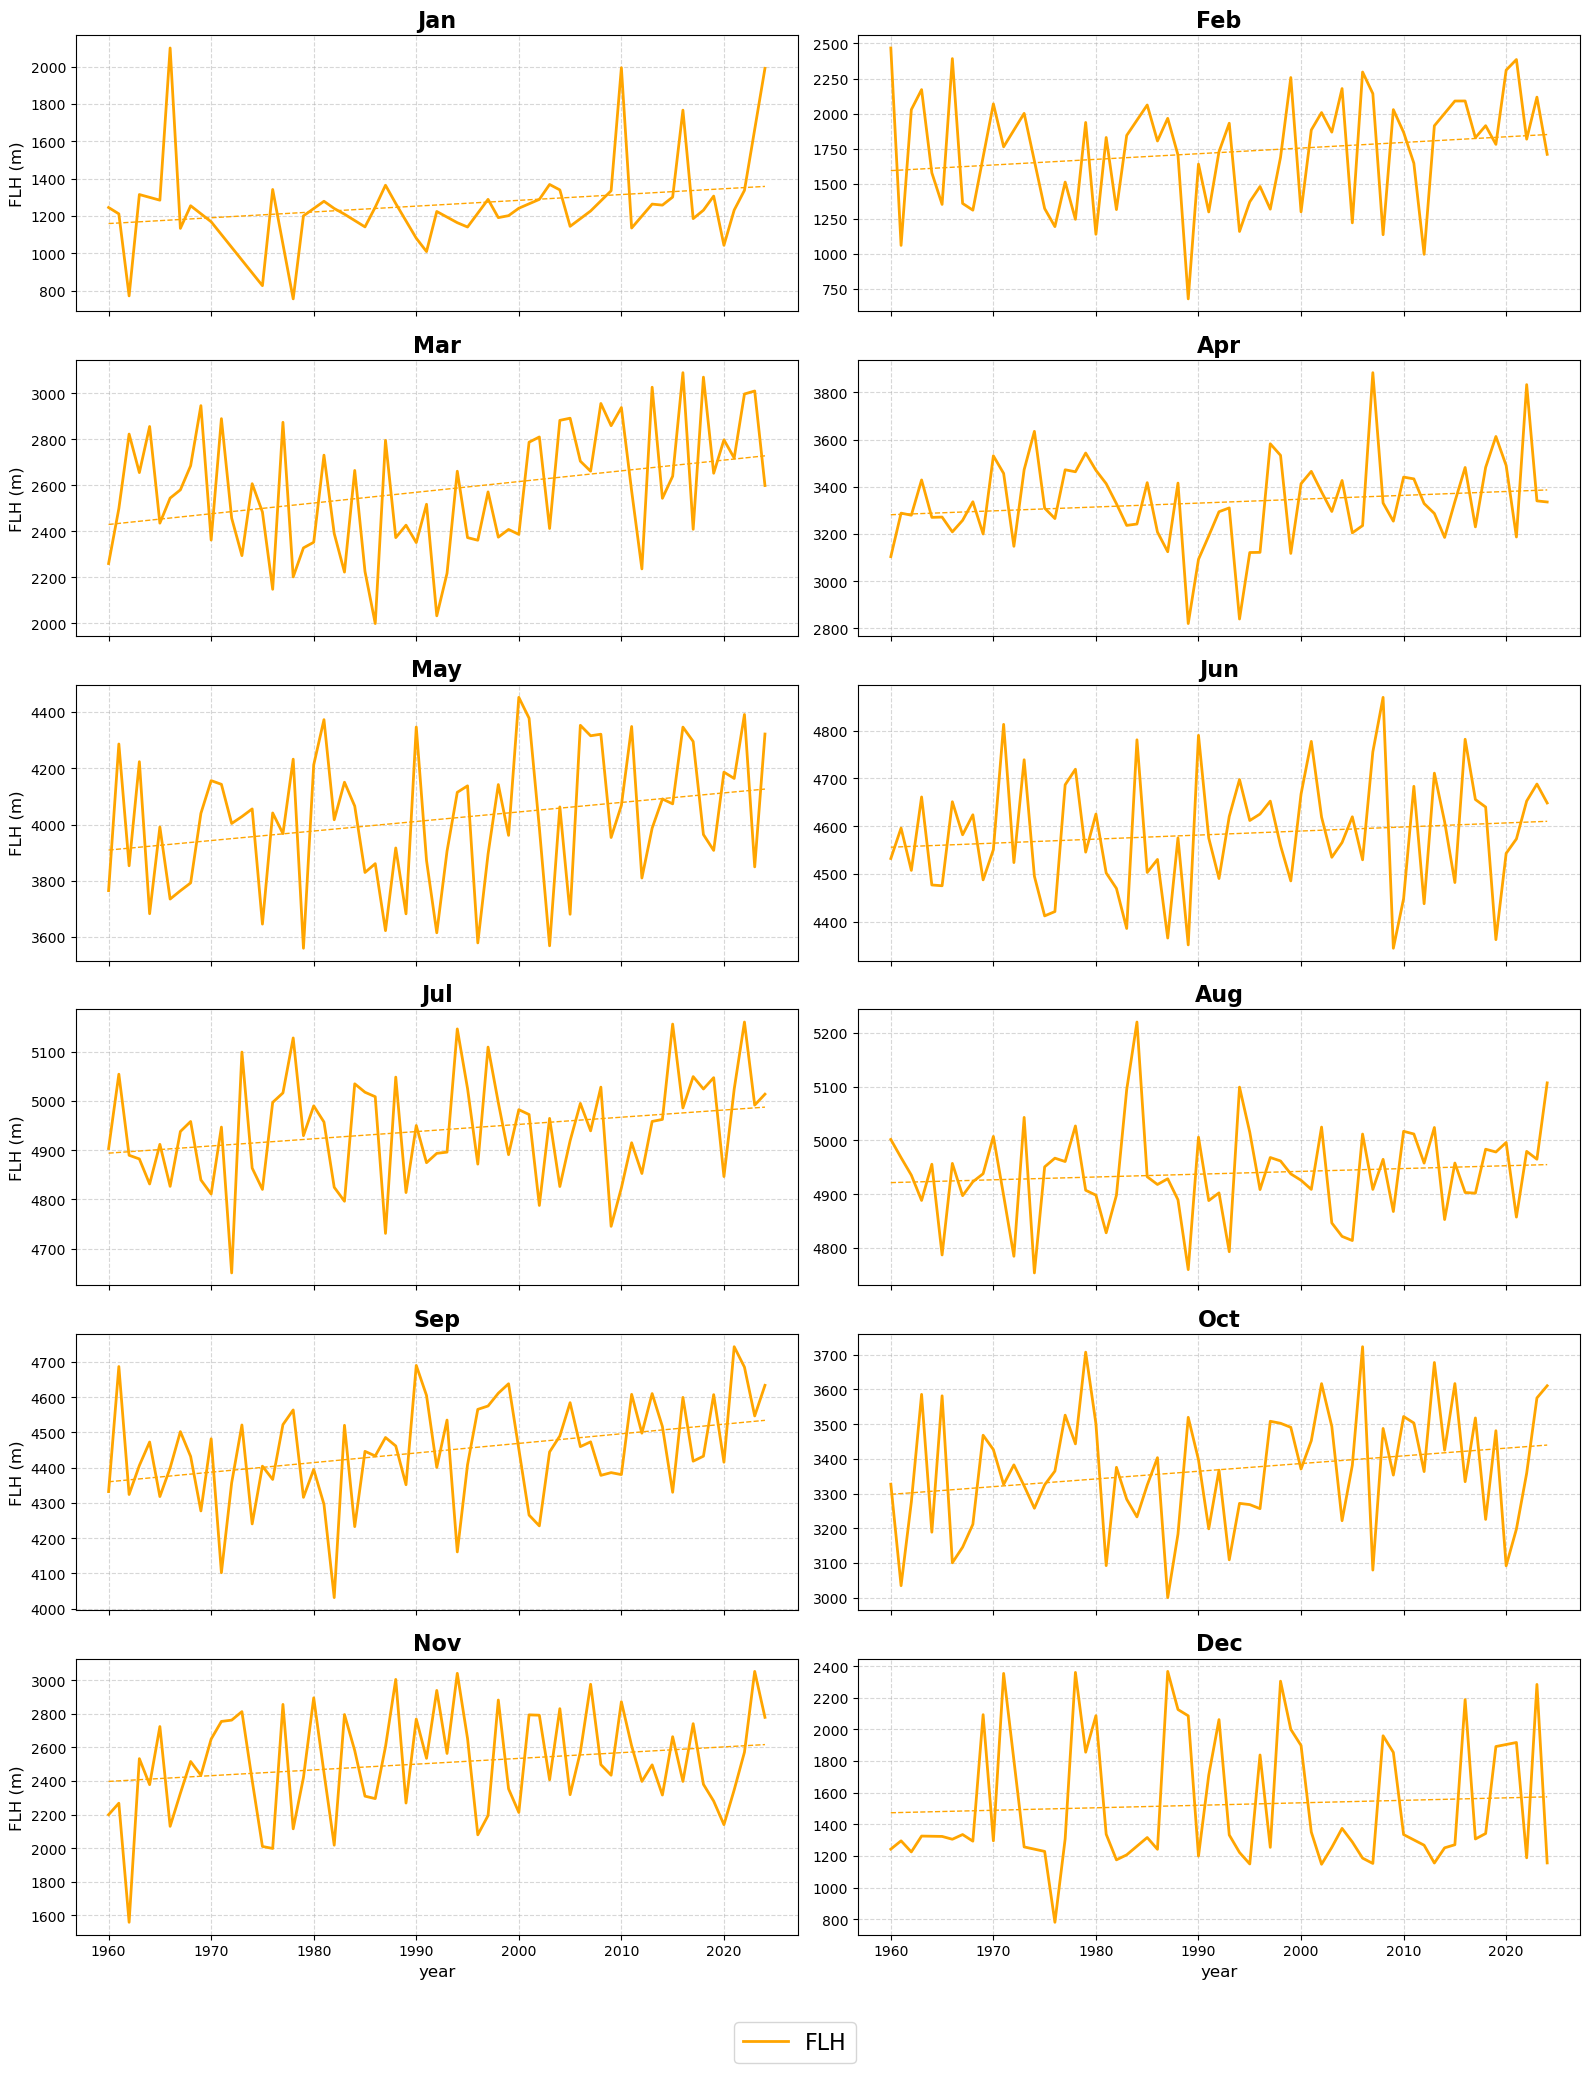

In [87]:
#====================== statistics tab ==============================================================================

table = pd.DataFrame(index=months, columns=['slope (m/decade)', 'slope (%/decade)', 'std (m)', 'std (%)'])
pvals = pd.DataFrame(index=months, columns=['slope (m/decade)', 'slope (%/decade)', 'std (m)', 'std (%)'])

for i in np.arange(1,13):

    FLH_slope = FLH_monthly_trends_stats[i][0] * 10
    FLH_pval  = FLH_monthly_trends_stats[i][3]
    FLH_slope_percentage = FLH_slope /  FLH_monthly_stats[i][0] * 100
    FLH_std = FLH_monthly_stats[i][1]
    FLH_std_percentage = FLH_std /  FLH_monthly_stats[i][0] * 100

    table.loc[months[i-1], 'slope (m/decade)'] = FLH_slope
    table.loc[months[i-1], 'slope (%/decade)'] = FLH_slope_percentage
    table.loc[months[i-1], 'std (m)'] = FLH_std
    table.loc[months[i-1], 'std (%)'] = FLH_std_percentage

    
    pvals.loc[months[i-1], 'slope (m/decade)'] = FLH_pval
    pvals.loc[months[i-1], 'slope (%/decade)'] = FLH_pval

def bold_sig(val, p):
    if p < 0.05:
        return 'font-weight: bold'
    return ''

formats = {
    'slope (m/decade)': "{:.0f}",
    'slope (%/decade)': "{:.1f}",
    'std (m)': "{:.0f}",      
    'std (%)': "{:.1f}"
}

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format(formats, na_rep='-')

display(styled_table)

#======================== plot ============================================================================================

fig, axes = plt.subplots(6, 2, figsize=(16,20))
axes = axes.flatten()

for i, ax in enumerate(axes):
    
    ax.plot(FLH_monthly_timeseries[i+1]['year'].values, FLH_monthly_timeseries[i+1]['FLH'].values, color='orange', label='FLH', linewidth=2)
    ax.plot(FLH_monthly_timeseries[i+1]['year'].values, FLH_monthly_trends[i+1], color='orange', linewidth=1, linestyle='--')

    ax.set_title(months[i], fontsize=16, weight="bold")
    
    if i in [0, 2, 4, 6, 8, 10]:  # colonne gauche
        ax.set_ylabel('FLH (m)', fontsize=12)
        
    if i in [10, 11]:  # ligne du bas
        ax.set_xlabel('year', fontsize=12)
    else:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    
# --- legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
    
plt.tight_layout()
plt.show()